<a href="https://colab.research.google.com/github/mananmalvi/ML--The-Art/blob/main/DAY_4_Types_of_Random_Sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DIFFERENT SAMPLING TECHNIQUES

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
x,y = make_classification(n_features=5 ,n_redundant=0, n_informative=4, n_clusters_per_class=1)
df=pd.DataFrame(x,columns=['col1','col2','col3','col4','col5'])

df['target']=y
print(df.shape)
df.head

(100, 6)


<bound method NDFrame.head of         col1      col2      col3      col4      col5  target
0   0.266819 -0.432154  1.319887  0.775278  1.900641       0
1  -1.187807 -1.737557  1.382477 -1.012403  1.160904       0
2   0.341069  0.964462  2.091321 -2.403069  0.237070       0
3  -0.187395 -1.176107 -0.637361 -0.138314  2.160950       0
4  -1.708367 -1.328954 -1.708126  0.903448  0.162235       1
..       ...       ...       ...       ...       ...     ...
95 -0.412713 -1.724869  0.797945  0.345345  2.664422       0
96 -2.389482 -2.374016 -1.228239 -0.090930  0.041302       1
97 -1.186253 -0.059703  1.760115  0.208215  0.181702       0
98 -0.889281 -1.541554  2.604354 -0.851419 -3.161498       1
99  0.510498  0.598462 -3.800552  0.575237 -0.599686       1

[100 rows x 6 columns]>

1. Row Sampling with Replacement (Bootstrapping) 🥾

In [3]:
"""1. Row Sampling with Replacement (Bootstrapping) 🥾
Concept: Har tree ko pure data ki jagah, randomly select kiya hua data "with replacement" milta hai. Is technique ko Bootstrap Sampling kehte hain, jisme ek hi row multiple times bhi aa sakti hai aur kuch rows poori tarah miss bhi ho sakti hain.
Why use it? Model alag-alag data patterns seekhta hai aur overfitting kam hoti hai. Jo rows chhoot jati hain, unhe Out-of-Bag (OOB) data kehte hain."""

'1. Row Sampling with Replacement (Bootstrapping) 🥾\nConcept: Har tree ko pure data ki jagah, randomly select kiya hua data "with replacement" milta hai. Is technique ko Bootstrap Sampling kehte hain, jisme ek hi row multiple times bhi aa sakti hai aur kuch rows poori tarah miss bhi ho sakti hain.\nWhy use it? Model alag-alag data patterns seekhta hai aur overfitting kam hoti hai. Jo rows chhoot jati hain, unhe Out-of-Bag (OOB) data kehte hain.'

In [4]:
def sample_rows(df, percent):
    return df.sample(int(percent * df.shape[0]), replace=True)

2. Row Sampling without Replacement (Pasting) 📋

In [5]:
"""2. Row Sampling without Replacement (Pasting) 📋
Concept: Agar sampling "without replacement" hoti hai, toh isko Pasting kehte hain. Isme ek baar jo row select ho gayi, wo dobara select nahi ho sakti. Agar 100 rows hain aur humne 70 select ki, toh sab unique hongi.
Why use it? Jab dataset bohot bada ho aur hum chahte hain ki model bilkul unique data points par train ho."""

'2. Row Sampling without Replacement (Pasting) 📋\nConcept: Agar sampling "without replacement" hoti hai, toh isko Pasting kehte hain. Isme ek baar jo row select ho gayi, wo dobara select nahi ho sakti. Agar 100 rows hain aur humne 70 select ki, toh sab unique hongi.\nWhy use it? Jab dataset bohot bada ho aur hum chahte hain ki model bilkul unique data points par train ho.'

In [6]:
# Function for Row Sampling without Replacement (Pasting)
def sample_rows_without_replacement(df, percent):
    # replace=False ensures every row picked is unique
    return df.sample(int(percent * df.shape[0]), replace=False)

3. Column Sampling (Random Subspaces) 🏛️

In [7]:
'''3. Column Sampling (Random Subspaces) 🏛️
Concept: Yahan hum rows ke sath chhed-chhad nahi karte, balki features (columns) ko sample karte hain. Har tree jab split banata hai, toh saare features ko nahi dekhta, balki randomly selected kuch features ko hi dekhta hai.
Why use it? Agar ek column bohot dominant hai (jaise 'salary' se sab kuch predict ho raha hai), toh saare trees usi column ko dekh kar split banayenge. Column sampling is dominant feature ko chupne (hide) ka mauka deti hai, jisse model baaki features se bhi seekhta hai.'''

"3. Column Sampling (Random Subspaces) 🏛️\nConcept: Yahan hum rows ke sath chhed-chhad nahi karte, balki features (columns) ko sample karte hain. Har tree jab split banata hai, toh saare features ko nahi dekhta, balki randomly selected kuch features ko hi dekhta hai.\nWhy use it? Agar ek column bohot dominant hai (jaise 'salary' se sab kuch predict ho raha hai), toh saare trees usi column ko dekh kar split banayenge. Column sampling is dominant feature ko chupne (hide) ka mauka deti hai, jisse model baaki features se bhi seekhta hai."

In [8]:
# Function for Column/Feature Sampling
def sample_columns(df, percent):
    # axis=1 means we are sampling across columns, not rows
    # replace=False because we don't want the same column twice
    return df.sample(int(percent * df.shape[1]), axis=1, replace=False)

In [9]:
def sample_features(df,percent):
  cols=random.sample(df.columns[:-1].tolist(),int(percent*len(df.columns)))
  return df[cols]

4. Row + Column Sampling (Random Patches) 🧩

In [10]:
'''4. Row + Column Sampling (Random Patches) 🧩
Concept: Dono ka mixture! Agar hum rows ke saath columns ki bhi sampling karte hain ek hi waqt par, toh usey Random Patches technique kehte hain. Random Forest internally basically yahi technique use karta hai!'''

'4. Row + Column Sampling (Random Patches) 🧩\nConcept: Dono ka mixture! Agar hum rows ke saath columns ki bhi sampling karte hain ek hi waqt par, toh usey Random Patches technique kehte hain. Random Forest internally basically yahi technique use karta hai!'

In [11]:
# Function for Row + Column Sampling (Random Patches)
def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

now checking performance of model over different bagging techniques

1. Model 1- for Row Sampling with Replacement (Bootstrapping) 🥾

In [12]:
#Yeh code exactly wahi kar raha hai jo Scikit-Learn ka RandomForestClassifier backend mein karta hai:
# Alag data -> Alag models -> Alag predictions.

In [13]:
# df1 = combined_sampling(df, 0.5, 0.5): humne data ko 3 alag parallel universes (samples) mein baant diya. Har sample ke paas sirf 50% rows aur 50% columns hain.
# print(df1.columns): Jab hum inko print karege, hum dekhege ki teeno dataframes ke features alag-alag hain. Kisi mein Column A aur C hoga, toh kisi mein B aur D. Yahi Column Sampling ki beauty hai!
# clf.fit(...): humne 3 alag Decision Trees (Base Learners) banaye aur unko is diverse data par train kar diya.
# plot_tree(clf1): Jab hum isko visualize karoge, hum dekhege ki teeno trees ka root node aur split logic bilkul alag hoga kyunki unhe data hi alag mila hai.

In [14]:
df1 = sample_rows(df, 0.1)
df2 = sample_rows(df, 0.5)
df3 = sample_rows(df, 0.8)

In [15]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [16]:
clf1.fit(df1.iloc[:, :-1], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, :-1], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, :-1], df3.iloc[:, -1])

DecisionTreeClassifier()

[Text(0.5, 0.9166666666666666, 'x[2] <= -0.268\ngini = 0.497\nsamples = 80\nvalue = [43, 37]'),
 Text(0.2, 0.75, 'x[4] <= -0.331\ngini = 0.239\nsamples = 36\nvalue = [5, 31]'),
 Text(0.35, 0.8333333333333333, 'True  '),
 Text(0.1, 0.5833333333333334, 'gini = 0.0\nsamples = 20\nvalue = [0, 20]'),
 Text(0.3, 0.5833333333333334, 'x[2] <= -0.876\ngini = 0.43\nsamples = 16\nvalue = [5, 11]'),
 Text(0.2, 0.4166666666666667, 'x[3] <= 0.559\ngini = 0.26\nsamples = 13\nvalue = [2, 11]'),
 Text(0.1, 0.25, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.3, 0.25, 'x[2] <= -3.083\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.2, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.4, 0.4166666666666667, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8, 0.75, 'x[4] <= -0.185\ngini = 0.236\nsamples = 44\nvalue = [38, 6]'),
 Text(0.65, 0.8333333333333333, '  False'),
 Text(0.7, 0.583333333

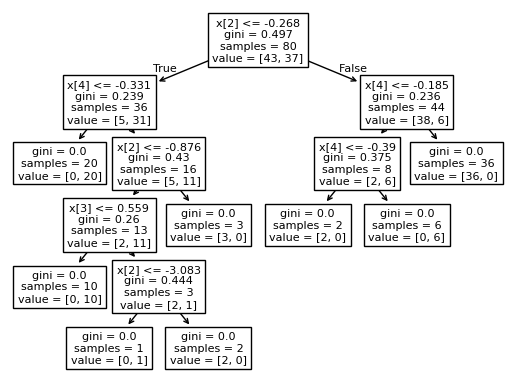

In [17]:
# i know i should make the 3 different cells , while plotting trees , but as of now , i'm just plotting 1 single tree
from sklearn.tree import plot_tree
plot_tree(clf1)
plot_tree(clf2)
plot_tree(clf3)

In [18]:
import numpy as np
import pandas as pd

# 1. Provide 5 values to match the 5 features the model was trained on.

query_point_raw = np.array([[0.45, 0.88, 0.12, 0.75, 0.33]])

# 2. Extract the exact feature names from your original dataset (excluding the Target column)
feature_cols = df.columns[:-1]

query_point_df = pd.DataFrame(query_point_raw, columns=feature_cols)

# 3. Extracting Individual Predictions from the Iron Legion
pred1 = clf1.predict(query_point_df)[0]
pred2 = clf2.predict(query_point_df)[0]
pred3 = clf3.predict(query_point_df)[0]

print(f"Tree 1 Prediction: {pred1}")
print(f"Tree 2 Prediction: {pred2}")
print(f"Tree 3 Prediction: {pred3}")

# 4. The Majority Vote
all_predictions = [pred1, pred2, pred3]
final_prediction = max(set(all_predictions), key=all_predictions.count)

print(f"\n🛡️ FINAL ENSEMBLE PREDICTION (Majority Vote): {final_prediction}")

Tree 1 Prediction: 0
Tree 2 Prediction: 0
Tree 3 Prediction: 0

🛡️ FINAL ENSEMBLE PREDICTION (Majority Vote): 0


2.Model 2 -for Row Sampling without Replacement (Pasting) 📋

In [19]:
df1=sample_rows_without_replacement(df,0.1)
df2=sample_rows_without_replacement(df,0.5)
df3=sample_rows_without_replacement(df,0.9)

In [20]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [22]:
clf1.fit(df1.iloc[:, :-1], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, :-1], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, :-1], df3.iloc[:, -1])

DecisionTreeClassifier()

[Text(0.5909090909090909, 0.9166666666666666, 'x[4] <= 0.647\ngini = 0.5\nsamples = 90\nvalue = [45, 45]'),
 Text(0.36363636363636365, 0.75, 'x[2] <= 0.998\ngini = 0.35\nsamples = 53\nvalue = [12, 41]'),
 Text(0.4772727272727273, 0.8333333333333333, 'True  '),
 Text(0.18181818181818182, 0.5833333333333334, 'x[0] <= -3.224\ngini = 0.142\nsamples = 39\nvalue = [3, 36]'),
 Text(0.09090909090909091, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2727272727272727, 0.4166666666666667, 'x[2] <= -0.149\ngini = 0.1\nsamples = 38\nvalue = [2, 36]'),
 Text(0.18181818181818182, 0.25, 'gini = 0.0\nsamples = 30\nvalue = [0, 30]'),
 Text(0.36363636363636365, 0.25, 'x[1] <= -0.972\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.2727272727272727, 0.08333333333333333, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.45454545454545453, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.5454545454545454, 0.5833333333333334, 'x[4] <= -1.508\ngini = 0.

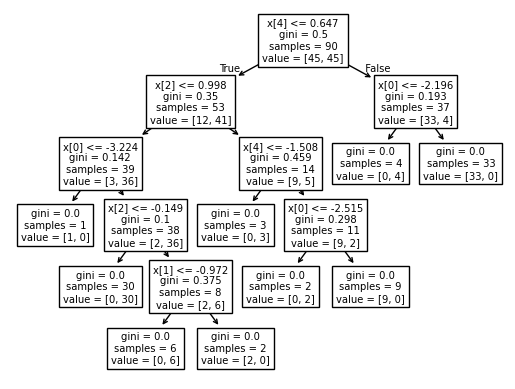

In [23]:
from sklearn.tree import plot_tree
plot_tree(clf1)
plot_tree(clf2)
plot_tree(clf3)

In [29]:
# 1. Incoming Threat Data
query_point_raw = np.array([[0.45, 0.88, 0.12, 0.75, 0.33]])

# 2. Extract feature names
feature_cols = df.columns[:-1]
query_point_df = pd.DataFrame(query_point_raw, columns=feature_cols)

# 3. Extracting Individual Predictions (NOTICE THE [0] AT THE END)
pred1 = clf1.predict(query_point_df)[0]
pred2 = clf2.predict(query_point_df)[0]
pred3 = clf3.predict(query_point_df)[0]

print(f"Tree 1 Prediction: {pred1}")
print(f"Tree 2 Prediction: {pred2}")
print(f"Tree 3 Prediction: {pred3}")

# 4. The majority Vote
all_predictions = [pred1, pred2, pred3]
final_prediction = max(set(all_predictions), key=all_predictions.count)

print(f"\n🛡️ FINAL ENSEMBLE PREDICTION (Majority Vote): {final_prediction}")

Tree 1 Prediction: 0
Tree 2 Prediction: 0
Tree 3 Prediction: 0

🛡️ FINAL ENSEMBLE PREDICTION (Majority Vote): 0


3.Model 3- for Column Sampling (Random Subspaces) 🏛️

In [38]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier

def sample_columns_upgrade(df, percent):
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    num_features = int(percent * X.shape[1])
    if num_features == 0:
        num_features = 1
    X_sampled = X.sample(n=num_features, axis=1, replace=False)
    return pd.concat([X_sampled, y], axis=1)


df1 = sample_columns_upgrade(df, 0.2)
df2 = sample_columns_upgrade(df, 0.5)
df3 = sample_columns_upgrade(df, 0.9)

print(f"DF1 Shape: {df1.shape} | Features (X): {df1.columns[:-1].tolist()}")
print(f"DF2 Shape: {df2.shape} | Features (X): {df2.columns[:-1].tolist()}")
print(f"DF3 Shape: {df3.shape} | Features (X): {df3.columns[:-1].tolist()}\n")

# Initialize and Train the Iron Legion
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

# NOW THIS WILL NOT CRASH!
clf1.fit(df1.iloc[:, :-1], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, :-1], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, :-1], df3.iloc[:, -1])

print("✅ Systems Nominal: Iron Legion (Trees) successfully trained!")

DF1 Shape: (100, 2) | Features (X): ['col1']
DF2 Shape: (100, 3) | Features (X): ['col2', 'col5']
DF3 Shape: (100, 5) | Features (X): ['col2', 'col1', 'col3', 'col4']

✅ Systems Nominal: Iron Legion (Trees) successfully trained!


[Text(0.421875, 0.95, 'x[2] <= -0.526\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.25, 0.85, 'x[1] <= -0.02\ngini = 0.153\nsamples = 36\nvalue = [3, 33]'),
 Text(0.3359375, 0.8999999999999999, 'True  '),
 Text(0.1875, 0.75, 'x[1] <= -0.279\ngini = 0.255\nsamples = 20\nvalue = [3, 17]'),
 Text(0.125, 0.65, 'x[3] <= 0.559\ngini = 0.188\nsamples = 19\nvalue = [2, 17]'),
 Text(0.0625, 0.55, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.1875, 0.55, 'x[3] <= 0.744\ngini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.125, 0.45, 'x[0] <= -0.128\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.0625, 0.35, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.1875, 0.35, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.25, 0.45, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.25, 0.65, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3125, 0.75, 'gini = 0.0\nsamples = 16\nvalue = [0, 16]'),
 Text(0.59375, 0.85, 'x[1] <= -2.459\ngini = 0.39\nsamples = 64\nvalue = 

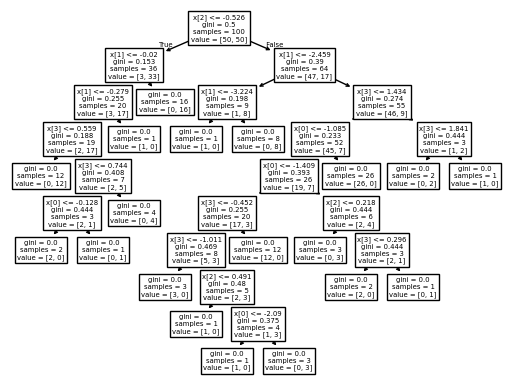

In [40]:
from sklearn.tree import plot_tree
plot_tree(clf1)
plot_tree(clf2)
plot_tree(clf3)

In [42]:
import numpy as np
import pandas as pd

# Step 1: Pehle check kar lo ki tumhare features hain kitne aur unke naam kya hain
original_features = df.columns[:-1]
print(f"J.A.R.V.I.S. Expects {len(original_features)} features: {original_features.tolist()}")

# Step 2: Input Payload ko theek karo (Ensure you pass exactly 5 values if original_features has 5)
# Maine yahan ek 5th value (0.25) add kar di hai.
query_raw = np.array([[0.8, 0.1, 0.45, 0.9, 0.25]])

# Step 3: Ab yeh seamlessly DataFrame mein convert ho jayega bina crash hue!
query_df = pd.DataFrame(query_raw, columns=original_features)
print("\n✅ Incoming Threat Data Ready:")
print(query_df, "\n")

# ==========================================
# 🎯 PREDICTION SEQUENCE
# ==========================================

# Step A: Filter features for clf1
clf1_features = clf1.feature_names_in_
query_for_clf1 = query_df[clf1_features]
pred1 = clf1.predict(query_for_clf1)[0]
print(f"🛡️ Tree 1 Prediction: {pred1}")

# Repeat for clf2 and clf3...
query_for_clf2 = query_df[clf2.feature_names_in_]
pred2 = clf2.predict(query_for_clf2)[0]
print(f"🛡️ Tree 2 Prediction: {pred2}")

query_for_clf3 = query_df[clf3.feature_names_in_]
pred3 = clf3.predict(query_for_clf3)[0]
print(f"🛡️ Tree 3 Prediction: {pred3}")

# Majority Voting
final_vote = max(set([pred1, pred2, pred3]), key=[pred1, pred2, pred3].count)
print(f"\n✅ Final Ensemble Prediction: {final_vote}")

J.A.R.V.I.S. Expects 5 features: ['col1', 'col2', 'col3', 'col4', 'col5']

✅ Incoming Threat Data Ready:
   col1  col2  col3  col4  col5
0   0.8   0.1  0.45   0.9  0.25 

🛡️ Tree 1 Prediction: 1
🛡️ Tree 2 Prediction: 0
🛡️ Tree 3 Prediction: 0

✅ Final Ensemble Prediction: 0


4. Model 4 - for Row + Column Sampling (Random Patches) 🧩

In [43]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier


def random_patches_upgrade(df, row_percent, col_percent):
    # Step A: Lock the Target column securely
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    # Step B: Row Sampling WITH Replacement (Bootstrapping)
    row_indices = X.sample(frac=row_percent, replace=True).index
    X_rows = X.loc[row_indices]
    y_rows = y.loc[row_indices]

    # Step C: Column Sampling (Ensure at least 1 feature remains)
    num_features = int(col_percent * X.shape[1])
    if num_features == 0:
        num_features = 1

    X_final = X_rows.sample(n=num_features, axis=1, replace=False)
    return pd.concat([X_final, y_rows], axis=1)


np.random.seed(42)
dummy_data = np.random.rand(100, 5)
df = pd.DataFrame(dummy_data, columns=['F1', 'F2', 'F3', 'F4', 'Target'])
df['Target'] = (df['Target'] > 0.5).astype(int)

# (e.g., 70% rows, 50% columns)
df1 = random_patches_upgrade(df, 0.7, 0.5)
df2 = random_patches_upgrade(df, 0.7, 0.5)
df3 = random_patches_upgrade(df, 0.7, 0.5)

print("--- TRAINING LOGS ---")
print(f"Tree 1 trained on: {df1.columns[:-1].tolist()} | Rows: {df1.shape[0]}")
print(f"Tree 2 trained on: {df2.columns[:-1].tolist()} | Rows: {df2.shape[0]}")
print(f"Tree 3 trained on: {df3.columns[:-1].tolist()} | Rows: {df3.shape[0]}\n")

# Train the Models
clf1 = DecisionTreeClassifier(random_state=42)
clf2 = DecisionTreeClassifier(random_state=42)
clf3 = DecisionTreeClassifier(random_state=42)

clf1.fit(df1.iloc[:, :-1], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, :-1], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, :-1], df3.iloc[:, -1])

original_features = df.columns[:-1]
query_raw = np.array([[0.8, 0.1, 0.45, 0.9]])
query_df = pd.DataFrame(query_raw, columns=original_features)

print("--- PREDICTION LOGS ---")
# Align features for each tree using .feature_names_in_
pred1 = clf1.predict(query_df[clf1.feature_names_in_])[0]
pred2 = clf2.predict(query_df[clf2.feature_names_in_])[0]
pred3 = clf3.predict(query_df[clf3.feature_names_in_])[0]

print(f"🛡️ Tree 1 Prediction: {pred1}")
print(f"🛡️ Tree 2 Prediction: {pred2}")
print(f"🛡️ Tree 3 Prediction: {pred3}")

# Majority Voting
final_vote = max(set([pred1, pred2, pred3]), key=[pred1, pred2, pred3].count)
print(f"\n✅ FINAL ENSEMBLE PREDICTION (Majority Vote): {final_vote}")

--- TRAINING LOGS ---
Tree 1 trained on: ['F1', 'F2'] | Rows: 70
Tree 2 trained on: ['F2', 'F1'] | Rows: 70
Tree 3 trained on: ['F4', 'F2'] | Rows: 70

--- PREDICTION LOGS ---
🛡️ Tree 1 Prediction: 1
🛡️ Tree 2 Prediction: 0
🛡️ Tree 3 Prediction: 1

✅ FINAL ENSEMBLE PREDICTION (Majority Vote): 1


[Text(0.5859375, 0.95, 'x[1] <= 0.858\ngini = 0.5\nsamples = 70\nvalue = [36, 34]'),
 Text(0.328125, 0.85, 'x[1] <= 0.14\ngini = 0.492\nsamples = 57\nvalue = [25, 32]'),
 Text(0.45703125, 0.8999999999999999, 'True  '),
 Text(0.125, 0.75, 'x[0] <= 0.484\ngini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.0625, 0.65, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.1875, 0.65, 'x[0] <= 0.654\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.125, 0.55, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.25, 0.55, 'x[1] <= 0.076\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1875, 0.45, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3125, 0.45, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.53125, 0.75, 'x[0] <= 0.098\ngini = 0.469\nsamples = 48\nvalue = [18, 30]'),
 Text(0.46875, 0.65, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.59375, 0.65, 'x[0] <= 0.206\ngini = 0.493\nsamples = 41\nvalue = [18.0, 23.0]'),
 Text(0.53125, 0.55, 'gini = 0.0\nsamples = 4\nva

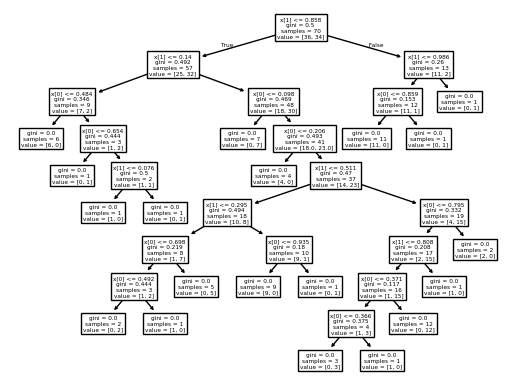

In [44]:
from sklearn.tree import plot_tree
plot_tree(clf1)
plot_tree(clf2)
plot_tree(clf3)